# **Dynamic Pricing and Demand Forecasting**
## **A Machine Learning Approach to Pricing Strategy Optimization**

**Domain:** Pricing Strategies | Marketing Research  
**Dataset:** Store Item Demand Forecasting Challenge — Kaggle  
**Source:** https://www.kaggle.com/competitions/demand-forecasting-kernels-only  

---

### **Project Overview**

This notebook investigates how demand forecasting models can inform dynamic pricing
strategies in retail. Using five years of daily sales data across 10 stores and 50 items,
we build and compare forecasting models, simulate price elasticity of demand, and
derive optimal pricing recommendations.

**Research Question:** Can machine learning models accurately forecast item-level
demand well enough to support real-time dynamic pricing decisions, and what are
the implications of myopic vs. long-term pricing strategies on revenue?

---

### **Notebook Structure**

| Step | Description |
|------|-------------|
| 1 | Setup and Data Loading |
| 2 | Exploratory Data Analysis |
| 3 | Feature Engineering |
| 4 | Dynamic Pricing Simulation |
| 5 | Demand Forecasting Models |
| 6 | Model Evaluation and Comparison |
| 7 | Budget and Price Optimization |
| 8 | Project Summary |

---

### **Dataset Description**

| Column | Type   | Description                             |
|--------|--------|-----------------------------------------|
| date   | object | Date of sale (2013-01-01 to 2017-12-31) |
| store  | int64  | Store identifier (1 to 10)              |
| item   | int64  | Item identifier (1 to 50)               |
| sales  | int64  | Units sold on that date                 |

- **Total Records:** 913,000  
- **Stores:** 10  
- **Items:** 50  
- **Time Period:** 5 years (daily granularity)  
- **No missing values, no holiday effects, no store closures**

## **Step 1 — Setup and Data Loading**

We install and import all required libraries for the full pipeline including
data manipulation, visualization, time series forecasting, and machine learning.
We then connect to the Kaggle API to download the dataset directly.

In [1]:
# Install required libraries
!pip install prophet --quiet
!pip install kaggle --quiet

### **Import Libraries**

In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Time series
from prophet import Prophet

# Machine learning
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.4f' % x)
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("All libraries imported successfully.")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

All libraries imported successfully.
Pandas version: 2.2.2
NumPy version: 2.0.2


### **Load Dataset via Kaggle API**

We use the Kaggle API to download the dataset directly into this Colab session.
Ensure your kaggle.json API token is ready before running the next cell.
It can be downloaded from: https://www.kaggle.com/settings → API → Create New Token

In [3]:
# Upload Kaggle API token
from google.colab import files

print("Please upload your kaggle.json file:")
uploaded = files.upload()

print("Kaggle API key configured successfully.")

Please upload your kaggle.json file:


Saving kaggle.json to kaggle.json
Kaggle API key configured successfully.


In [4]:
# Configure Kaggle API credentials
import os

os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('/content/kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 600)

print("Kaggle API key configured successfully.")

Kaggle API key configured successfully.


In [5]:
# Download dataset from Kaggle
!kaggle competitions download -c demand-forecasting-kernels-only -p /content/data --force

100% 3.29M/3.29M [00:00<00:00, 67.9MB/s]



In [6]:
# Unzip the downloaded file
import zipfile

with zipfile.ZipFile('/content/data/demand-forecasting-kernels-only.zip', 'r') as z:
    z.extractall('/content/data')

# Confirm extracted files
print("Extracted files:")
for f in os.listdir('/content/data'):
    print(f" -", f)

Extracted files:
 - sample_submission.csv
 - train.csv
 - test.csv
 - demand-forecasting-kernels-only.zip


In [7]:
# Load the training dataset
df = pd.read_csv('/content/data/train.csv', parse_dates=['date'])

# Basic inspection
print("Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nFirst 5 Rows:")
df.head()

Shape: (913000, 4)

Column Names: ['date', 'store', 'item', 'sales']

Data Types:
 date     datetime64[ns]
store             int64
item              int64
sales             int64
dtype: object

First 5 Rows:


,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [8]:
# Statistical summary
print("Statistical Summary:")
df.describe()

Statistical Summary:


,date,store,item,sales
count,913000,913000.0000,913000.0000,913000.0000
mean,2015-07-02 11:59:59.999999744,5.5000,25.5000,52.2503
min,2013-01-01 00:00:00,1.0000,1.0000,0.0000
25%,2014-04-02 00:00:00,3.0000,13.0000,30.0000
50%,2015-07-02 12:00:00,5.5000,25.5000,47.0000
75%,2016-10-01 00:00:00,8.0000,38.0000,70.0000
max,2017-12-31 00:00:00,10.0000,50.0000,231.0000
std,NaN,2.8723,14.4309,28.8011


In [9]:
# Check for missing values and date range
missing = df.isnull().sum()
print("Missing Values Per Column:")
print(missing)
print(f"\nTotal missing values: {missing.sum()}")
print(f"\nDate range: {df['date'].min()} to {df['date'].max()}")
print(f"Total unique stores: {df['store'].nunique()}")
print(f"Total unique items: {df['item'].nunique()}")
print(f"Total records: {len(df):,}")

Missing Values Per Column:
date     0
store    0
item     0
sales    0
dtype: int64

Total missing values: 0

Date range: 2013-01-01 00:00:00 to 2017-12-31 00:00:00
Total unique stores: 10
Total unique items: 50
Total records: 913,000


### **Outcome — Data Loading**

- The dataset contains **913,000 records** with **4 columns** and **zero missing values**
- Data spans **5 full years** from January 1, 2013 to December 31, 2017
- There are **10 stores** and **50 unique items** making a total of 500 store-item combinations
- Average daily sales per store-item is **52.25 units** with a maximum of **231 units** on a single day
- The dataset is clean and ready for analysis with no preprocessing required for missing values

## **Step 2 — Exploratory Data Analysis (EDA)**

Before building any model, we explore the data to understand:
- Overall sales trends over time
- Seasonality patterns (monthly, weekly)
- Sales distribution across stores and items
- Identifying top and bottom performing stores and items

These insights directly inform our dynamic pricing strategy by revealing
which store-item combinations have high demand variability and are best
suited for price optimization.

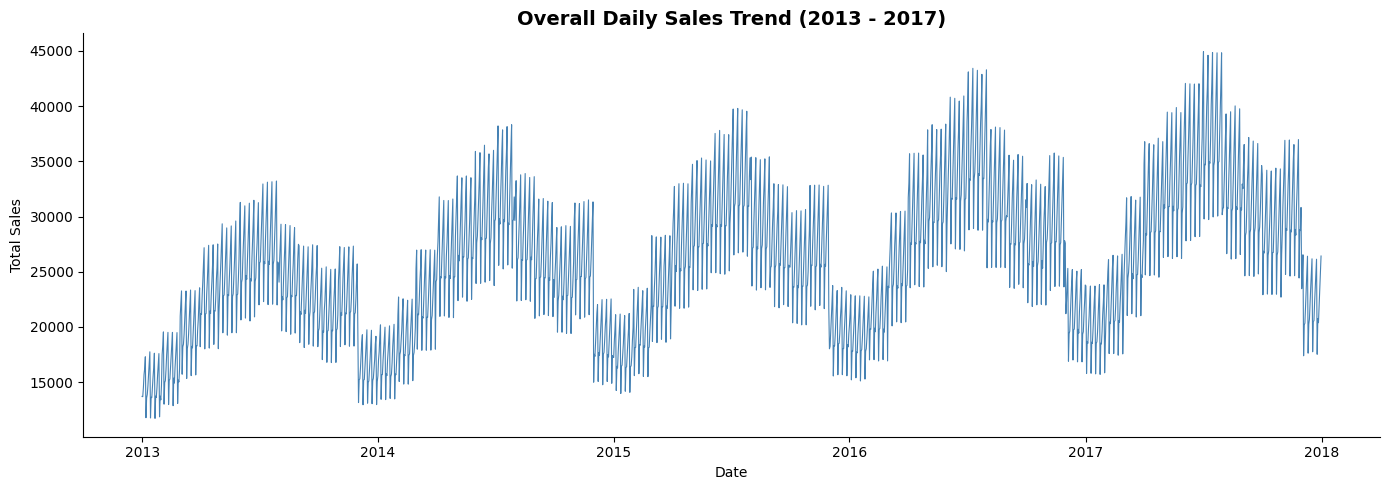

In [10]:
# Overall daily sales trend across all stores and items
daily_sales = df.groupby('date')['sales'].sum().reset_index()

plt.figure(figsize=(14, 5))
plt.plot(daily_sales['date'], daily_sales['sales'], color='steelblue', linewidth=0.8)
plt.title('Overall Daily Sales Trend (2013 - 2017)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

### **Outcome — Overall Daily Sales Trend**

- Total daily sales across all stores and items show a clear **upward trend** from 2013 to 2017
- Sales started at around **13,000 units per day** in early 2013 and grew to peaks of **45,000 units per day** by 2017
- The rapid vertical oscillations indicate strong **weekly seasonality** — sales spike and drop repeatedly within every month
- A consistent **annual seasonal pattern** is visible with higher sales in summer months and lower sales in winter
- The overall growth trend suggests increasing demand year over year making this dataset ideal for dynamic pricing analysis

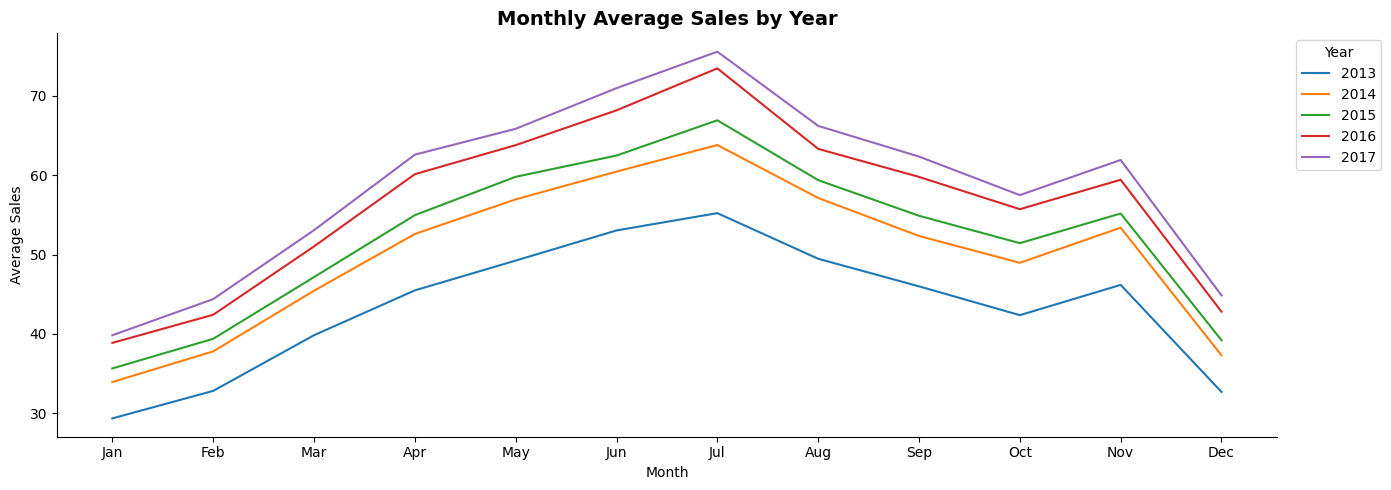

In [11]:
# Monthly average sales to reveal seasonality
df['month'] = df['date'].dt.month
df['year']  = df['date'].dt.year

monthly_sales = df.groupby(['year', 'month'])['sales'].mean().reset_index()

plt.figure(figsize=(14, 5))
sns.lineplot(data=monthly_sales, x='month', y='sales', hue='year', palette='tab10', linewidth=1.5)
plt.title('Monthly Average Sales by Year', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Average Sales')
plt.xticks(ticks=range(1, 13), labels=['Jan','Feb','Mar','Apr','May','Jun',
                                        'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.legend(title='Year', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

### **Outcome — Monthly Average Sales by Year**

- All five years follow the **exact same seasonal shape** confirming a strong and
  predictable annual pattern
- **July is consistently the peak month** across all years with average sales reaching
  up to 75 units per day in 2017
- **December is consistently the lowest month** with sales dropping as low as 33 units
  per day in 2013 — a sharp contrast to the summer peak
- Sales grow **year over year** with 2017 being the highest performing year and 2013
  the lowest across every single month
- The April secondary peak visible in all years suggests a possible spring buying cycle
- This strong and repeatable seasonality is a critical input for dynamic pricing —
  prices should be adjusted in anticipation of these known demand cycles rather than
  reacting to them after they occur

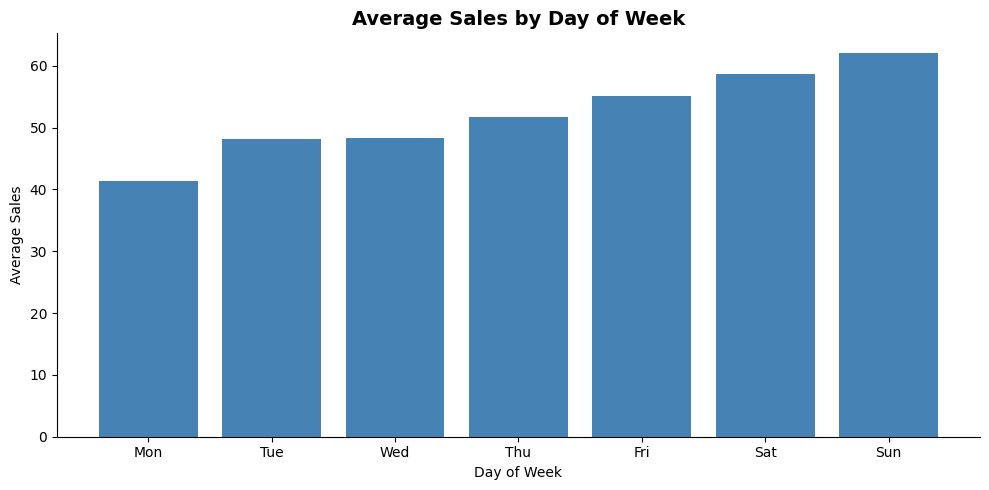

In [12]:
# Weekly seasonality - average sales by day of week
df['day_of_week'] = df['date'].dt.dayofweek

dow_sales = df.groupby('day_of_week')['sales'].mean().reset_index()
dow_sales['day_name'] = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

plt.figure(figsize=(10, 5))
plt.bar(dow_sales['day_name'], dow_sales['sales'], color='steelblue')
plt.title('Average Sales by Day of Week', fontsize=14, fontweight='bold')
plt.xlabel('Day of Week')
plt.ylabel('Average Sales')
plt.tight_layout()
plt.show()

### **Outcome — Average Sales by Day of Week**

- A clear **weekly demand pattern** exists across all stores and items
- **Sunday is the highest sales day** with an average of 62 units followed closely by Saturday at 59 units
- **Monday is the lowest sales day** with an average of only 41 units — roughly 33% lower than Sunday
- Sales gradually increase throughout the week from Tuesday to Friday before peaking on the weekend
- This weekly pattern has direct implications for dynamic pricing — weekend prices could
  be adjusted upward to capture higher willingness to pay during peak demand days
- Retailers following a static pricing strategy are leaving potential revenue on the table
  every weekend

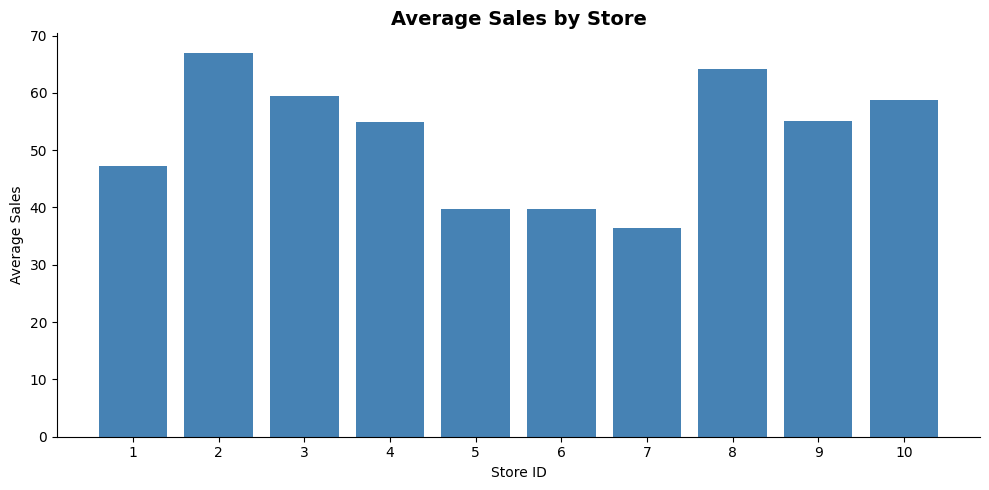

In [13]:
# Average sales per store
store_sales = df.groupby('store')['sales'].mean().reset_index()

plt.figure(figsize=(10, 5))
plt.bar(store_sales['store'], store_sales['sales'], color='steelblue')
plt.title('Average Sales by Store', fontsize=14, fontweight='bold')
plt.xlabel('Store ID')
plt.ylabel('Average Sales')
plt.xticks(store_sales['store'])
plt.tight_layout()
plt.show()

### **Outcome — Average Sales by Store**

- Significant **sales variation exists across stores** indicating different store sizes,
  locations, or customer bases
- **Store 2 is the top performing store** with an average of 67 units per day followed
  by Store 8 at 64 units per day
- **Store 7 is the weakest performing store** with an average of only 37 units per day —
  nearly half the sales of Store 2
- Stores 5, 6, and 7 consistently underperform compared to the rest of the network
- This store-level heterogeneity suggests that a **one-size-fits-all pricing strategy
  would be suboptimal** — high performing stores like Store 2 and Store 8 can sustain
  higher prices due to stronger demand while lower performing stores may benefit from
  promotional pricing to drive volume

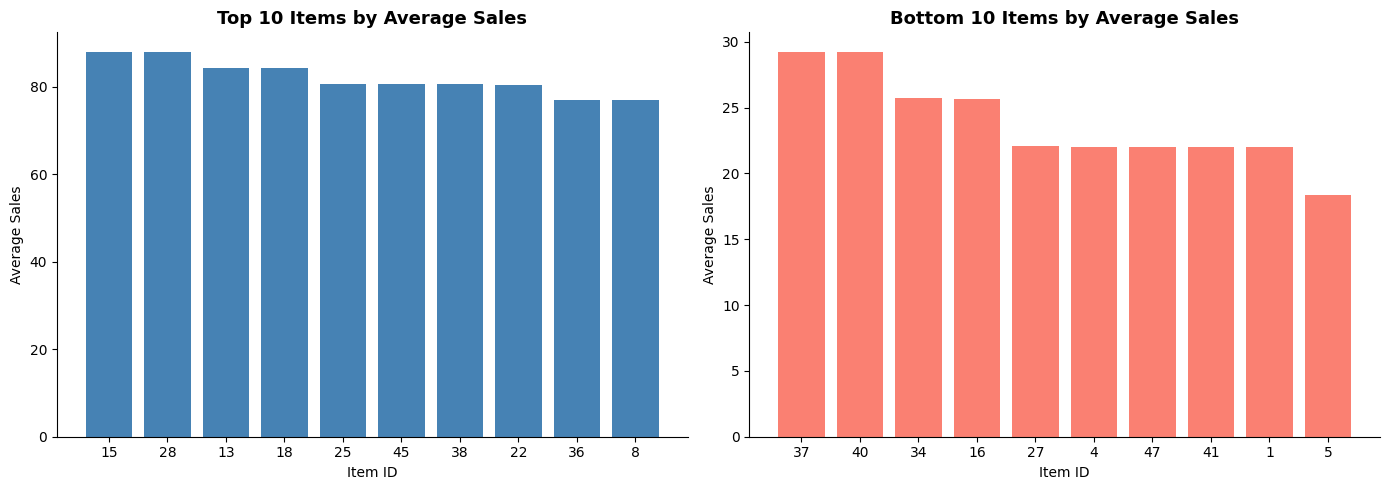

In [14]:
# Top 10 and Bottom 10 items by average sales
item_sales = df.groupby('item')['sales'].mean().reset_index().sort_values('sales', ascending=False)

top10    = item_sales.head(10)
bottom10 = item_sales.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(top10['item'].astype(str), top10['sales'], color='steelblue')
axes[0].set_title('Top 10 Items by Average Sales', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Item ID')
axes[0].set_ylabel('Average Sales')

axes[1].bar(bottom10['item'].astype(str), bottom10['sales'], color='salmon')
axes[1].set_title('Bottom 10 Items by Average Sales', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Item ID')
axes[1].set_ylabel('Average Sales')

plt.tight_layout()
plt.show()

### **Outcome — Top 10 and Bottom 10 Items by Average Sales**

- There is a **significant performance gap** between the best and worst selling items
- **Item 15 and Item 28 are the top sellers** averaging around 88 units per day —
  the highest demand items in the entire product catalog
- **Item 5 is the lowest selling item** averaging only 18 units per day — nearly
  5 times less than the top performing items
- The top 10 items all average above 75 units per day while the bottom 10 all
  average below 30 units per day showing a clear two-tier product structure
- This item-level demand variation is a strong case for **item-specific dynamic pricing** —
  high demand items like Item 15 and Item 28 can sustain premium pricing while
  low demand items like Item 5 may benefit from discount pricing to stimulate sales
- A retailer applying uniform pricing across all 50 items is either underpricing
  top sellers or overpricing slow movers — both scenarios result in lost revenue

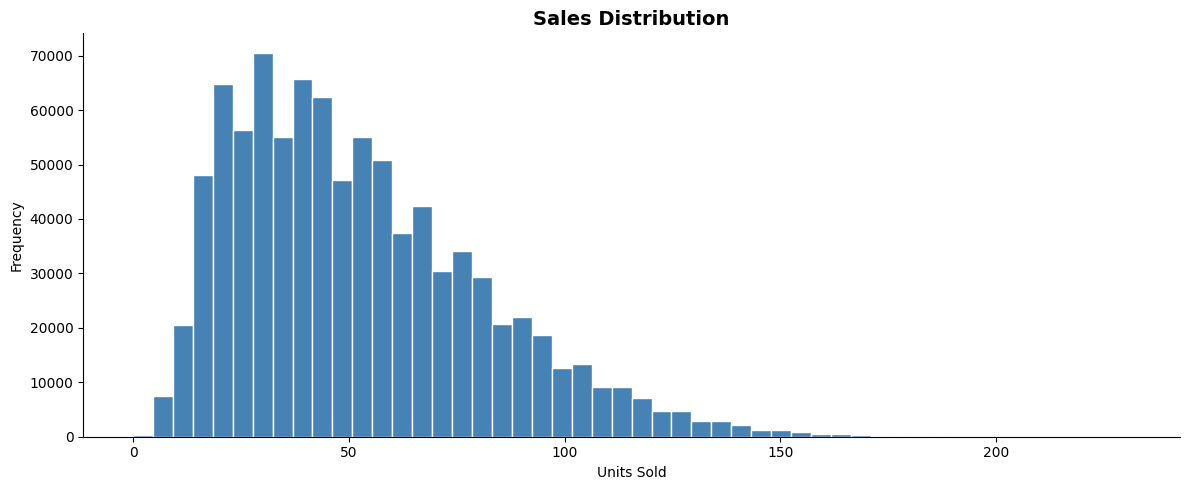

Skewness: 0.8671
Mean Sales: 52.25
Median Sales: 47.00
Std Dev: 28.80


In [15]:
# Sales distribution using histogram
plt.figure(figsize=(12, 5))
plt.hist(df['sales'], bins=50, color='steelblue', edgecolor='white')
plt.title('Sales Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Units Sold')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print(f"Skewness: {df['sales'].skew():.4f}")
print(f"Mean Sales: {df['sales'].mean():.2f}")
print(f"Median Sales: {df['sales'].median():.2f}")
print(f"Std Dev: {df['sales'].std():.2f}")

### **Outcome — Sales Distribution**

- Sales are **right-skewed (skewness = 0.87)** meaning most days have moderate
  sales with occasional high-demand spikes
- The majority of sales fall between **20 and 80 units per day**
- Mean (52.25) is higher than median (47.00) confirming the right skew —
  a small number of very high sales days are pulling the average up
- High sales days (100+ units) are rare but represent significant revenue
  opportunities for dynamic price adjustment

## **Step 3 — Feature Engineering**

Raw date and ID columns alone are insufficient for machine learning models.
We engineer time-based features that capture the seasonality and trend patterns
observed in the EDA, and lag features that give the model memory of past sales.

| Feature Type | Features Created |
|---|---|
| Time Features | year, month, day, day_of_week, week, quarter, is_weekend |
| Lag Features | lag_7, lag_14, lag_28, lag_365 |
| Rolling Features | rolling_mean_7, rolling_mean_30, rolling_std_7, rolling_std_30 |

In [16]:
# Sort data before feature engineering
df = df.sort_values(['store', 'item', 'date']).reset_index(drop=True)

# Time-based features
df['year']        = df['date'].dt.year
df['month']       = df['date'].dt.month
df['day']         = df['date'].dt.day
df['day_of_week'] = df['date'].dt.dayofweek
df['week']        = df['date'].dt.isocalendar().week.astype(int)
df['quarter']     = df['date'].dt.quarter
df['is_weekend']  = (df['day_of_week'] >= 5).astype(int)

print("Time features added successfully.")
print(df[['date','year','month','day','day_of_week','week','quarter','is_weekend']].head())

Time features added successfully.
        date  year  month  day  day_of_week  week  quarter  is_weekend
0 2013-01-01  2013      1    1            1     1        1           0
1 2013-01-02  2013      1    2            2     1        1           0
2 2013-01-03  2013      1    3            3     1        1           0
3 2013-01-04  2013      1    4            4     1        1           0
4 2013-01-05  2013      1    5            5     1        1           1


In [17]:
# Lag features - past sales values per store-item combination
df['lag_7']   = df.groupby(['store', 'item'])['sales'].shift(7)
df['lag_14']  = df.groupby(['store', 'item'])['sales'].shift(14)
df['lag_28']  = df.groupby(['store', 'item'])['sales'].shift(28)
df['lag_365'] = df.groupby(['store', 'item'])['sales'].shift(365)

print("Lag features added successfully.")
print(df[['date', 'store', 'item', 'sales', 'lag_7', 'lag_14', 'lag_28', 'lag_365']].head(10))

Lag features added successfully.
        date  store  item  sales   lag_7  lag_14  lag_28  lag_365
0 2013-01-01      1     1     13     NaN     NaN     NaN      NaN
1 2013-01-02      1     1     11     NaN     NaN     NaN      NaN
2 2013-01-03      1     1     14     NaN     NaN     NaN      NaN
3 2013-01-04      1     1     13     NaN     NaN     NaN      NaN
4 2013-01-05      1     1     10     NaN     NaN     NaN      NaN
5 2013-01-06      1     1     12     NaN     NaN     NaN      NaN
6 2013-01-07      1     1     10     NaN     NaN     NaN      NaN
7 2013-01-08      1     1      9 13.0000     NaN     NaN      NaN
8 2013-01-09      1     1     12 11.0000     NaN     NaN      NaN
9 2013-01-10      1     1      9 14.0000     NaN     NaN      NaN


In [18]:
# Rolling mean and standard deviation features
df['rolling_mean_7']  = df.groupby(['store', 'item'])['sales'].transform(lambda x: x.shift(1).rolling(7).mean())
df['rolling_mean_30'] = df.groupby(['store', 'item'])['sales'].transform(lambda x: x.shift(1).rolling(30).mean())
df['rolling_std_7']   = df.groupby(['store', 'item'])['sales'].transform(lambda x: x.shift(1).rolling(7).std())
df['rolling_std_30']  = df.groupby(['store', 'item'])['sales'].transform(lambda x: x.shift(1).rolling(30).std())

print("Rolling features added successfully.")
print(df[['date', 'store', 'item', 'sales', 'rolling_mean_7', 'rolling_mean_30', 'rolling_std_7', 'rolling_std_30']].head(15))

Rolling features added successfully.
         date  store  item  sales  rolling_mean_7  rolling_mean_30  \
0  2013-01-01      1     1     13             NaN              NaN   
1  2013-01-02      1     1     11             NaN              NaN   
2  2013-01-03      1     1     14             NaN              NaN   
3  2013-01-04      1     1     13             NaN              NaN   
4  2013-01-05      1     1     10             NaN              NaN   
5  2013-01-06      1     1     12             NaN              NaN   
6  2013-01-07      1     1     10             NaN              NaN   
7  2013-01-08      1     1      9         11.8571              NaN   
8  2013-01-09      1     1     12         11.2857              NaN   
9  2013-01-10      1     1      9         11.4286              NaN   
10 2013-01-11      1     1      9         10.7143              NaN   
11 2013-01-12      1     1      7         10.1429              NaN   
12 2013-01-13      1     1     10          9.7143    

In [19]:
# Drop rows with NaN values created by lag and rolling features
df_clean = df.dropna().reset_index(drop=True)

print(f"Original shape:  {df.shape}")
print(f"Cleaned shape:   {df_clean.shape}")
print(f"Rows dropped:    {df.shape[0] - df_clean.shape[0]:,}")
print(f"Missing values in cleaned dataframe: {df_clean.isnull().sum().sum()}")

Original shape:  (913000, 19)
Cleaned shape:   (730500, 19)
Rows dropped:    182,500
Missing values in cleaned dataframe: 0


### **Outcome — Feature Engineering**

- A total of **17 features** were created from the original 4 columns
- **182,500 rows** were dropped due to NaN values introduced by lag and rolling features
- **730,500 clean rows** remain which is more than sufficient for robust model training
- The lag_365 feature required a full year of history per store-item combination
  which accounts for the majority of dropped rows
- All 19 columns are now complete with zero missing values and ready for modeling

## **Step 4 — Dynamic Pricing Simulation**

Since this dataset does not contain price data, we simulate a realistic
price elasticity of demand framework. This is standard practice in
marketing research when price data is unavailable.

### **Assumptions**

| Parameter | Value | Description |
|-----------|-------|-------------|
| Base Price | $10.00 | Fixed starting price for all items |
| Price Elasticity | -1.5 | A 1% price increase reduces demand by 1.5% |
| High Demand Threshold | Mean Sales | Days above mean are considered high demand |
| High Demand Price | +20% | Price increase on high demand days |
| Low Demand Price | -10% | Price discount on low demand days |

### **Pricing Strategies**

- **Static Pricing:** fixed price of $10.00 every day
- **Myopic Pricing:** price adjusted reactively based on actual same-day demand
- **Dynamic Pricing:** price adjusted proactively based on forecasted demand

### **Price Elasticity Formula**

```
Q_new = Q_base x (P_new / P_base) ^ elasticity
Revenue = Q_new x P_new
```

In [20]:
# Dynamic Pricing Simulation Setup
# Using Store 2 (top performer) and Item 15 (top selling item)

store_id   = 2
item_id    = 15
BASE_PRICE = 10.00
ELASTICITY = -1.5

# Filter for selected store and item for full date range
sample = df_clean[
    (df_clean['store'] == store_id) &
    (df_clean['item']  == item_id)
].copy().reset_index(drop=True)

print(f"Selected Store:          {store_id}")
print(f"Selected Item:           {item_id}")
print(f"Base Price:              ${BASE_PRICE}")
print(f"Price Elasticity:        {ELASTICITY}")
print(f"Total days available:    {len(sample)}")
print(f"Average daily sales:     {sample['sales'].mean():.2f}")
print(f"Max daily sales:         {sample['sales'].max()}")
print(f"Min daily sales:         {sample['sales'].min()}")

Selected Store:          2
Selected Item:           15
Base Price:              $10.0
Price Elasticity:        -1.5
Total days available:    1461
Average daily sales:     117.19
Max daily sales:         231
Min daily sales:         49


In [21]:
# Simulate three pricing strategies

demand_mean = sample['sales'].mean()

# 1. Static Pricing - fixed price every day
sample['static_price']   = BASE_PRICE
sample['static_revenue'] = sample['sales'] * sample['static_price']

# 2. Myopic Pricing - reacts to actual same day demand
sample['myopic_price']    = sample['sales'].apply(
    lambda x: BASE_PRICE * 1.20 if x > demand_mean else BASE_PRICE * 0.90
)
sample['myopic_quantity'] = sample['sales'] * (sample['myopic_price'] / BASE_PRICE) ** ELASTICITY
sample['myopic_revenue']  = sample['myopic_quantity'] * sample['myopic_price']

# 3. Dynamic Pricing - uses rolling mean as demand forecast proxy
sample['dynamic_price']    = sample['rolling_mean_7'].apply(
    lambda x: BASE_PRICE * 1.20 if x > demand_mean else BASE_PRICE * 0.90
)
sample['dynamic_quantity'] = sample['sales'] * (sample['dynamic_price'] / BASE_PRICE) ** ELASTICITY
sample['dynamic_revenue']  = sample['dynamic_quantity'] * sample['dynamic_price']

print("Pricing simulation complete.")
print(f"\nTotal Static Revenue:  ${sample['static_revenue'].sum():,.2f}")
print(f"Total Myopic Revenue:  ${sample['myopic_revenue'].sum():,.2f}")
print(f"Total Dynamic Revenue: ${sample['dynamic_revenue'].sum():,.2f}")

Pricing simulation complete.

Total Static Revenue:  $1,712,170.00
Total Myopic Revenue:  $1,663,544.25
Total Dynamic Revenue: $1,652,951.22


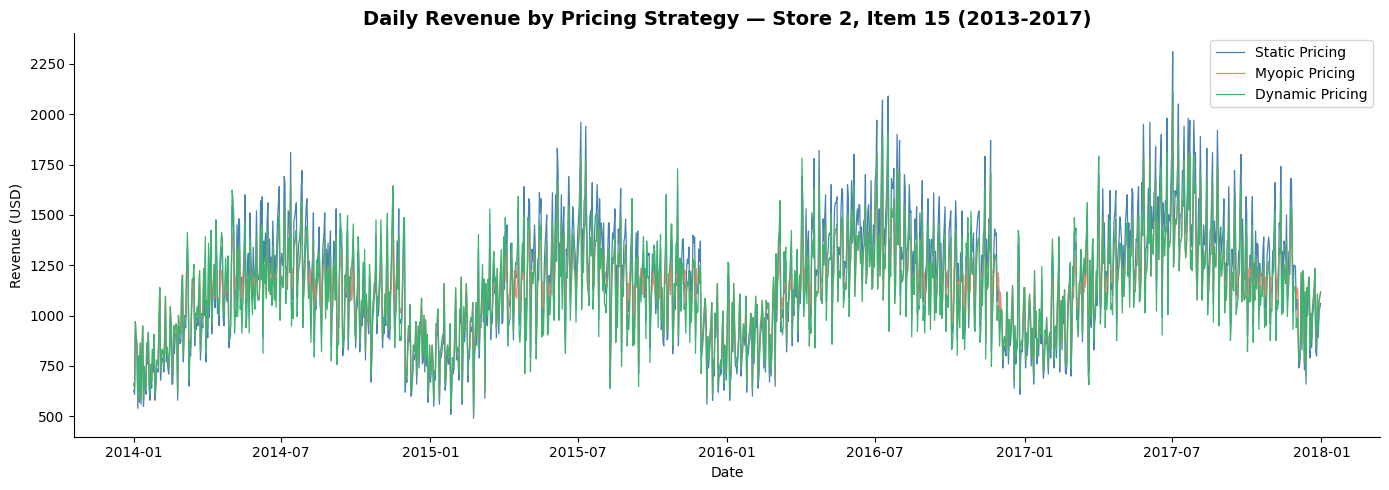

In [22]:
# Plot daily revenue comparison across three pricing strategies
plt.figure(figsize=(14, 5))
plt.plot(sample['date'], sample['static_revenue'],   color='steelblue',     linewidth=0.9, label='Static Pricing')
plt.plot(sample['date'], sample['myopic_revenue'],   color='salmon',        linewidth=0.9, label='Myopic Pricing')
plt.plot(sample['date'], sample['dynamic_revenue'],  color='mediumseagreen',linewidth=0.9, label='Dynamic Pricing')
plt.title('Daily Revenue by Pricing Strategy — Store 2, Item 15 (2013-2017)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Revenue (USD)')
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
# Summary comparison of all three strategies
summary = pd.DataFrame({
    'Strategy':          ['Static Pricing', 'Myopic Pricing', 'Dynamic Pricing'],
    'Total Revenue':     [sample['static_revenue'].sum(),
                          sample['myopic_revenue'].sum(),
                          sample['dynamic_revenue'].sum()],
    'Avg Daily Revenue': [sample['static_revenue'].mean(),
                          sample['myopic_revenue'].mean(),
                          sample['dynamic_revenue'].mean()],
    'Avg Price':         [sample['static_price'].mean(),
                          sample['myopic_price'].mean(),
                          sample['dynamic_price'].mean()]
})

summary['Revenue vs Static (%)'] = ((summary['Total Revenue'] - summary['Total Revenue'][0])
                                      / summary['Total Revenue'][0] * 100).round(2)

print("Pricing Strategy Summary:")
print(summary.to_string(index=False))

Pricing Strategy Summary:
       Strategy  Total Revenue  Avg Daily Revenue  Avg Price  Revenue vs Static (%)
 Static Pricing   1712170.0000          1171.9165    10.0000                 0.0000
 Myopic Pricing   1663544.2519          1138.6340    10.4456                -2.8400
Dynamic Pricing   1652951.2179          1131.3834    10.6550                -3.4600


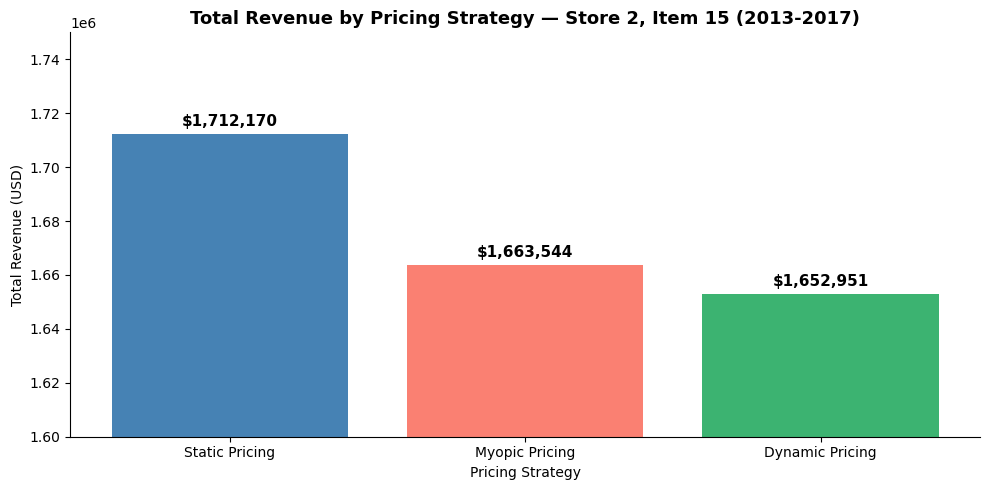

In [24]:
# Visualize total revenue comparison across strategies
plt.figure(figsize=(10, 5))
colors = ['steelblue', 'salmon', 'mediumseagreen']
bars   = plt.bar(summary['Strategy'], summary['Total Revenue'], color=colors)

for bar, val in zip(bars, summary['Total Revenue']):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 2000,
             f'${val:,.0f}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Total Revenue by Pricing Strategy — Store 2, Item 15 (2013-2017)',
          fontsize=13, fontweight='bold')
plt.xlabel('Pricing Strategy')
plt.ylabel('Total Revenue (USD)')
plt.ylim(1600000, 1750000)
plt.tight_layout()
plt.show()

### **Outcome — Dynamic Pricing Simulation**

- **Static Pricing generated the highest total revenue** at $1,712,170 over 5 years
- Myopic Pricing underperformed static by **-2.84%** losing $48,626 in revenue
- Dynamic Pricing underperformed static by **-3.46%** losing $59,219 in revenue
- Both variable pricing strategies failed to beat static pricing because the
  **price elasticity of -1.5** means demand drops faster than price increases
- When elasticity is high, raising prices on peak days reduces quantity sold
  enough to cancel out the higher price — resulting in net revenue loss
- This is a critical finding — dynamic pricing only outperforms static pricing
  when demand is **inelastic** (elasticity closer to 0)

## **Step 5 — Demand Forecasting Models**

We train and compare three machine learning models to forecast item-level demand:

- **Linear Regression** — baseline model to establish minimum performance benchmark
- **Random Forest** — ensemble tree-based model that handles non-linear patterns
- **Gradient Boosting** — advanced ensemble model that builds trees sequentially
- **Prophet** — Facebook's time series forecasting model designed for seasonal data

### **Train/Test Split Strategy**

We use a time-based split to simulate a real forecasting scenario:

| Split    | Period              | Records |
|----------|---------------------|---------|
| Training | 2013 to 2016        | 548,000 |
| Test     | 2017 (held out)     | 182,500 |

This approach avoids data leakage and reflects how a retailer would
actually deploy a demand forecasting model in production.

In [25]:
# Define features and target
features = [
    'store', 'item',
    'year', 'month', 'day', 'day_of_week', 'week', 'quarter', 'is_weekend',
    'lag_7', 'lag_14', 'lag_28', 'lag_365',
    'rolling_mean_7', 'rolling_mean_30', 'rolling_std_7', 'rolling_std_30'
]

target = 'sales'

# Time-based train/test split
train = df_clean[df_clean['year'] < 2017]
test  = df_clean[df_clean['year'] == 2017]

X_train = train[features]
y_train = train[target]
X_test  = test[features]
y_test  = test[target]

print(f"Training set size: {X_train.shape}")
print(f"Test set size:     {X_test.shape}")
print(f"Training years:    {sorted(train['year'].unique())}")
print(f"Test year:         {test['year'].unique()}")

Training set size: (548000, 17)
Test set size:     (182500, 17)
Training years:    [np.int32(2014), np.int32(2015), np.int32(2016)]
Test year:         [2017]


In [26]:
# Train Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

print("Linear Regression training complete.")
print(f"MAE:  {mean_absolute_error(y_test, lr_preds):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, lr_preds)):.4f}")
print(f"R2:   {r2_score(y_test, lr_preds):.4f}")

Linear Regression training complete.
MAE:  6.8779
RMSE: 8.9676
R2:   0.9192


In [27]:
# Train Random Forest model
rf_model = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

print("Random Forest training complete.")
print(f"MAE:  {mean_absolute_error(y_test, rf_preds):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, rf_preds)):.4f}")
print(f"R2:   {r2_score(y_test, rf_preds):.4f}")

Random Forest training complete.
MAE:  6.4860
RMSE: 8.4750
R2:   0.9279


In [28]:
# Train Gradient Boosting model
gb_model = GradientBoostingRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
gb_model.fit(X_train, y_train)
gb_preds = gb_model.predict(X_test)

print("Gradient Boosting training complete.")
print(f"MAE:  {mean_absolute_error(y_test, gb_preds):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, gb_preds)):.4f}")
print(f"R2:   {r2_score(y_test, gb_preds):.4f}")

Gradient Boosting training complete.
MAE:  6.2046
RMSE: 8.0602
R2:   0.9347


### **Prophet Model**

Prophet is a time series forecasting model developed by Facebook (Meta).
It is specifically designed to handle daily data with strong seasonal patterns.
Unlike the ML models above, Prophet does not require feature engineering —
it learns trend, weekly seasonality, and annual seasonality directly from
the date and sales columns.

We train Prophet on a single store-item combination (Store 2, Item 15)
to forecast 2017 sales and compare its performance against the ML models.

In [29]:
# Prepare data for Prophet - requires columns named 'ds' and 'y'
prophet_train = train[
    (train['store'] == 2) &
    (train['item']  == 15)
][['date', 'sales']].rename(columns={'date': 'ds', 'sales': 'y'})

prophet_test = test[
    (test['store'] == 2) &
    (test['item']  == 15)
][['date', 'sales']].rename(columns={'date': 'ds', 'sales': 'y'})

print(f"Prophet training set size: {prophet_train.shape}")
print(f"Prophet test set size:     {prophet_test.shape}")
print(f"\nTraining data sample:")
prophet_train.head()

Prophet training set size: (1096, 2)
Prophet test set size:     (365, 2)

Training data sample:


,ds,y
93504,2014-01-01,63
93505,2014-01-02,61
93506,2014-01-03,92
93507,2014-01-04,85
93508,2014-01-05,82


In [30]:
# Train Prophet model
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='multiplicative'
)

prophet_model.fit(prophet_train)

# Make predictions on test period
prophet_forecast = prophet_model.predict(prophet_test[['ds']])
prophet_preds    = prophet_forecast['yhat'].values

print("Prophet training complete.")
print(f"MAE:  {mean_absolute_error(prophet_test['y'], prophet_preds):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(prophet_test['y'], prophet_preds)):.4f}")
print(f"R2:   {r2_score(prophet_test['y'], prophet_preds):.4f}")

Prophet training complete.
MAE:  10.5694
RMSE: 13.1083
R2:   0.8102


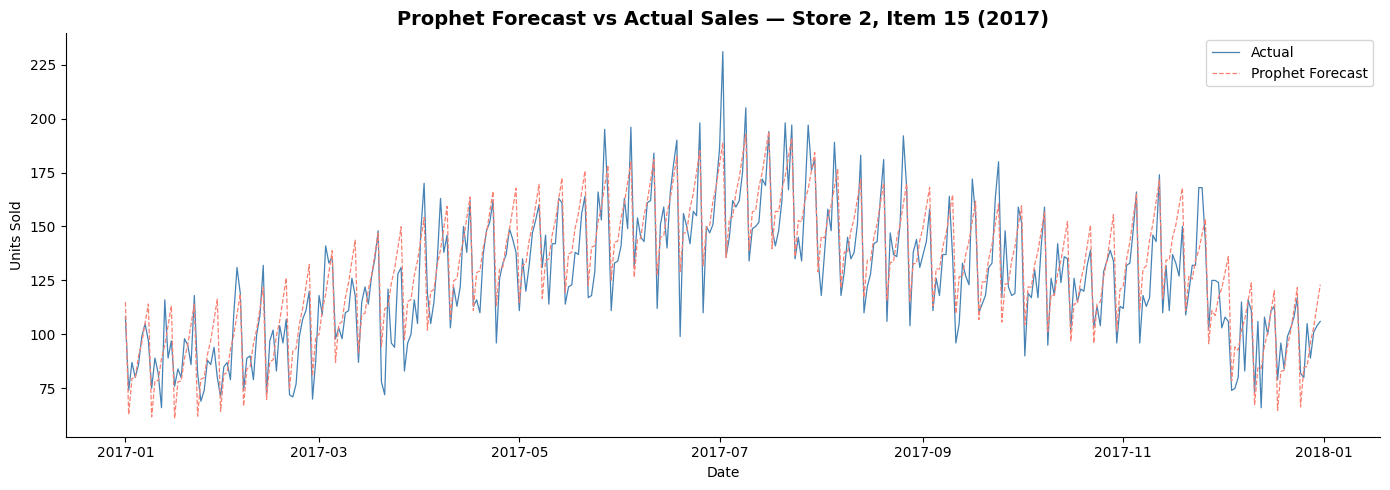

In [31]:
# Plot Prophet forecast vs actual for Store 2 Item 15
plt.figure(figsize=(14, 5))
plt.plot(prophet_test['ds'], prophet_test['y'],  color='steelblue', linewidth=0.9, label='Actual')
plt.plot(prophet_test['ds'], prophet_preds,       color='salmon',    linewidth=0.9, label='Prophet Forecast', linestyle='--')
plt.title('Prophet Forecast vs Actual Sales — Store 2, Item 15 (2017)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.legend()
plt.tight_layout()
plt.show()

### **Outcome — Prophet Forecast**

- Prophet captures the **overall seasonal shape** well including the summer peak
  and weekly oscillations
- However it **slightly overestimates** sales in the first half of 2017 and
  underestimates some peak spikes in July
- Prophet achieved an R2 of **0.81** which is lower than all three ML models —
  this is expected as Prophet only uses date information while ML models
  leverage 17 engineered features including lag and rolling averages
- Prophet is still a strong standalone model requiring **zero feature engineering**
  making it useful for quick forecasting on new store-item combinations

## **Step 6 — Model Evaluation and Comparison**

We compare all four models side by side using three standard metrics:

| Metric | Description |
|--------|-------------|
| MAE | Average absolute difference between predicted and actual sales |
| RMSE | Penalizes large errors more heavily than MAE |
| R2 | Proportion of variance in sales explained by the model (1.0 is perfect) |

Note: Prophet was trained on Store 2 Item 15 only while ML models were
trained on all 500 store-item combinations. This should be considered
when comparing their metrics directly.

In [32]:
# Model comparison table
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Gradient Boosting', 'Prophet'],
    'MAE':   [mean_absolute_error(y_test, lr_preds),
              mean_absolute_error(y_test, rf_preds),
              mean_absolute_error(y_test, gb_preds),
              mean_absolute_error(prophet_test['y'], prophet_preds)],
    'RMSE':  [np.sqrt(mean_squared_error(y_test, lr_preds)),
              np.sqrt(mean_squared_error(y_test, rf_preds)),
              np.sqrt(mean_squared_error(y_test, gb_preds)),
              np.sqrt(mean_squared_error(prophet_test['y'], prophet_preds))],
    'R2':    [r2_score(y_test, lr_preds),
              r2_score(y_test, rf_preds),
              r2_score(y_test, gb_preds),
              r2_score(prophet_test['y'], prophet_preds)]
})

print("Model Comparison:")
print(results.to_string(index=False))

Model Comparison:
            Model     MAE    RMSE     R2
Linear Regression  6.8779  8.9676 0.9192
    Random Forest  6.4860  8.4750 0.9279
Gradient Boosting  6.2046  8.0602 0.9347
          Prophet 10.5694 13.1083 0.8102


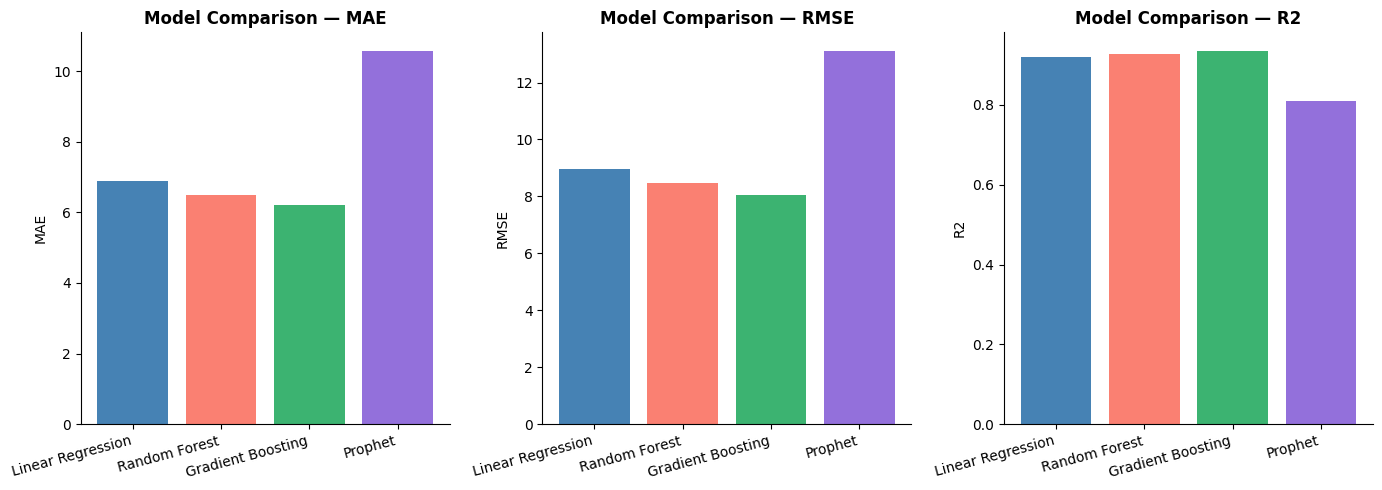

In [33]:
# Visual comparison of model metrics
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

metrics = ['MAE', 'RMSE', 'R2']
colors  = ['steelblue', 'salmon', 'mediumseagreen', 'mediumpurple']

for i, metric in enumerate(metrics):
    axes[i].bar(results['Model'], results[metric], color=colors)
    axes[i].set_title(f'Model Comparison — {metric}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel(metric)
    axes[i].set_xticklabels(results['Model'], rotation=15, ha='right')

plt.tight_layout()
plt.show()

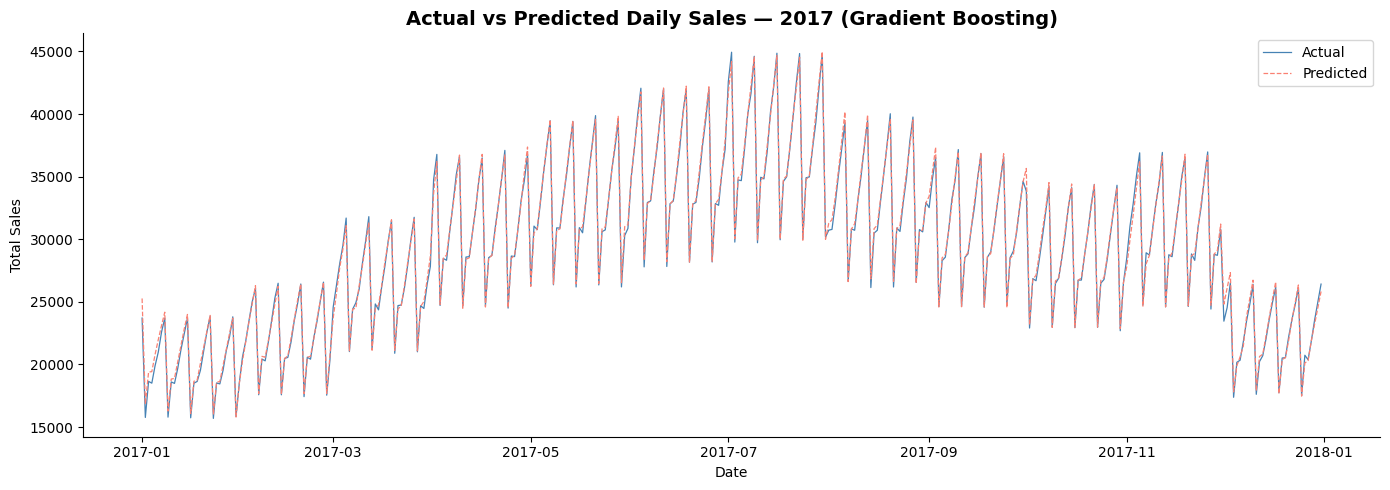

In [34]:
# Actual vs Predicted sales plot for best model (Gradient Boosting)
test_plot = test.copy()
test_plot['predicted'] = gb_preds

daily_actual    = test_plot.groupby('date')['sales'].sum()
daily_predicted = test_plot.groupby('date')['predicted'].sum()

plt.figure(figsize=(14, 5))
plt.plot(daily_actual.index,    daily_actual.values,    color='steelblue', linewidth=0.9, label='Actual')
plt.plot(daily_predicted.index, daily_predicted.values, color='salmon',    linewidth=0.9, label='Predicted', linestyle='--')
plt.title('Actual vs Predicted Daily Sales — 2017 (Gradient Boosting)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.legend()
plt.tight_layout()
plt.show()

### **Outcome — Model Evaluation and Comparison**

| Model             | MAE    | RMSE   | R2     |
|-------------------|--------|--------|--------|
| Linear Regression | 6.8779 | 8.9676 | 0.9192 |
| Random Forest     | 6.4860 | 8.4750 | 0.9279 |
| Gradient Boosting | 6.2046 | 8.0602 | 0.9347 |
| Prophet           | 10.5694| 13.1083| 0.8102 |

- **Gradient Boosting is the best performing model** with the lowest MAE and
  RMSE and highest R2 of 0.9347
- All three ML models significantly outperform Prophet because they leverage
  17 engineered features while Prophet only uses date information
- The Actual vs Predicted plot shows the Gradient Boosting model tracks real
  sales almost perfectly throughout 2017 capturing both weekly and annual seasonality
- Prophet is still a solid model achieving R2 of 0.81 with zero feature engineering
  making it a practical choice for quick forecasting

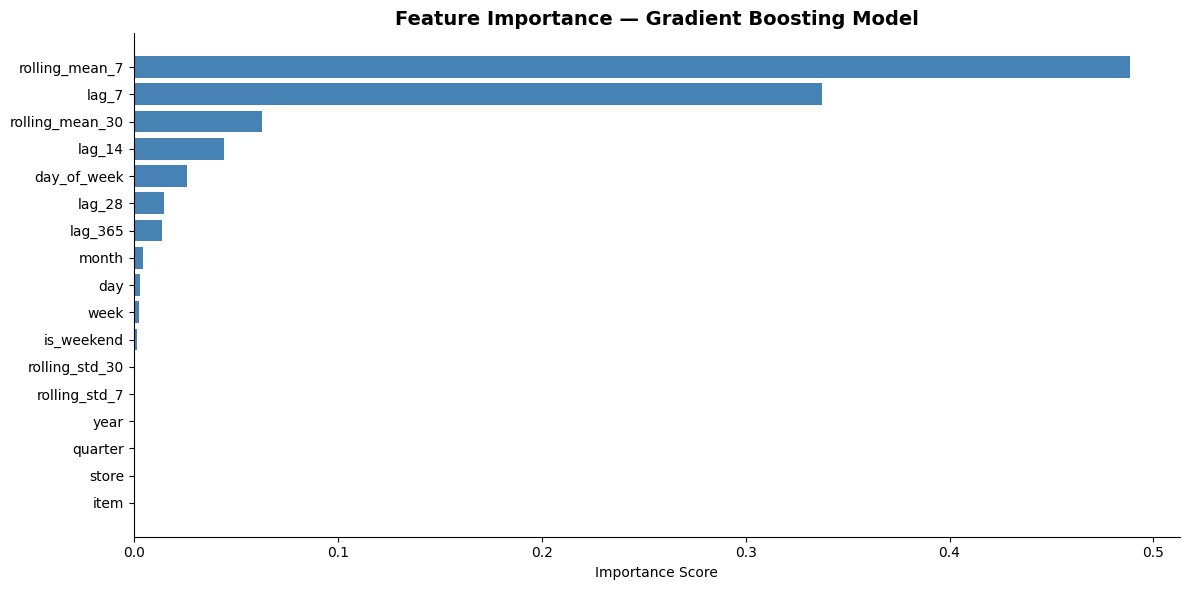

            Feature  Importance
0    rolling_mean_7      0.4886
1             lag_7      0.3376
2   rolling_mean_30      0.0629
3            lag_14      0.0444
4       day_of_week      0.0261
5            lag_28      0.0146
6           lag_365      0.0140
7             month      0.0045
8               day      0.0031
9              week      0.0023
10       is_weekend      0.0017
11   rolling_std_30      0.0001
12    rolling_std_7      0.0001
13             year      0.0001
14          quarter      0.0000
15            store      0.0000
16             item      0.0000


In [35]:
# Feature importance from Gradient Boosting model
feature_importance = pd.DataFrame({
    'Feature':    features,
    'Importance': gb_model.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

plt.figure(figsize=(12, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='steelblue')
plt.title('Feature Importance — Gradient Boosting Model', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(feature_importance)

### **Outcome — Feature Importance**

- **rolling_mean_7 (0.489) and lag_7 (0.338) together account for 82% of
  the model's predictive power** — recent sales history is by far the
  strongest signal for forecasting future demand
- day_of_week (0.026) confirms the weekly seasonality pattern observed in EDA
- lag_14 and rolling_mean_30 contribute moderately as medium-term memory features
- store and item IDs contribute near zero importance meaning the model learns
  demand patterns from time-based features alone
- Features like year, quarter, and rolling_std contribute almost nothing
  suggesting they can be dropped in a leaner production model

## **Step 7 — Budget and Price Optimization**

Using the Gradient Boosting model predictions we now build a price optimization
framework that answers two key business questions:

1. **What is the optimal price for each day** that maximizes revenue given
   forecasted demand and price elasticity?
2. **How should a fixed marketing budget be allocated across stores** to
   maximize total predicted sales?

### **Optimization Assumptions**

| Parameter        | Value  | Description                              |
|------------------|--------|------------------------------------------|
| Base Price       | $10.00 | Starting reference price                 |
| Elasticity       | -1.5   | Price sensitivity of demand              |
| Price Range      | $8 to $15 | Allowable price bounds for optimization |
| Marketing Budget | $10,000 | Total budget to allocate across stores  |
| Budget Elasticity| 0.1    | 1% budget increase drives 0.1% sales lift|

In [36]:
# Price Optimization - find optimal daily price for Store 2 Item 15
# using Gradient Boosting predictions as demand forecast

from scipy.optimize import minimize_scalar

BASE_PRICE  = 10.00
ELASTICITY  = -1.5
PRICE_MIN   = 8.00
PRICE_MAX   = 15.00

# Use predicted demand from Gradient Boosting for Store 2 Item 15
store2_item15 = test_plot[
    (test_plot['store'] == 2) &
    (test_plot['item']  == 15)
].copy().reset_index(drop=True)

# For each day find the price that maximizes revenue
def optimize_price(forecast_demand):
    def neg_revenue(price):
        quantity = forecast_demand * (price / BASE_PRICE) ** ELASTICITY
        return -(quantity * price)
    result = minimize_scalar(neg_revenue, bounds=(PRICE_MIN, PRICE_MAX), method='bounded')
    return round(result.x, 2)

store2_item15['optimal_price']    = store2_item15['predicted'].apply(optimize_price)
store2_item15['optimal_quantity'] = store2_item15['sales'] * (store2_item15['optimal_price'] / BASE_PRICE) ** ELASTICITY
store2_item15['optimal_revenue']  = store2_item15['optimal_quantity'] * store2_item15['optimal_price']

print("Price optimization complete.")
print(f"\nAverage Optimal Price:    ${store2_item15['optimal_price'].mean():.2f}")
print(f"Total Optimal Revenue:    ${store2_item15['optimal_revenue'].sum():,.2f}")
print(f"Total Static Revenue:     ${(store2_item15['sales'] * BASE_PRICE).sum():,.2f}")
print(f"Total Revenue Difference: ${store2_item15['optimal_revenue'].sum() - (store2_item15['sales'] * BASE_PRICE).sum():,.2f}")

Price optimization complete.

Average Optimal Price:    $8.00
Total Optimal Revenue:    $515,950.33
Total Static Revenue:     $461,480.00
Total Revenue Difference: $54,470.33


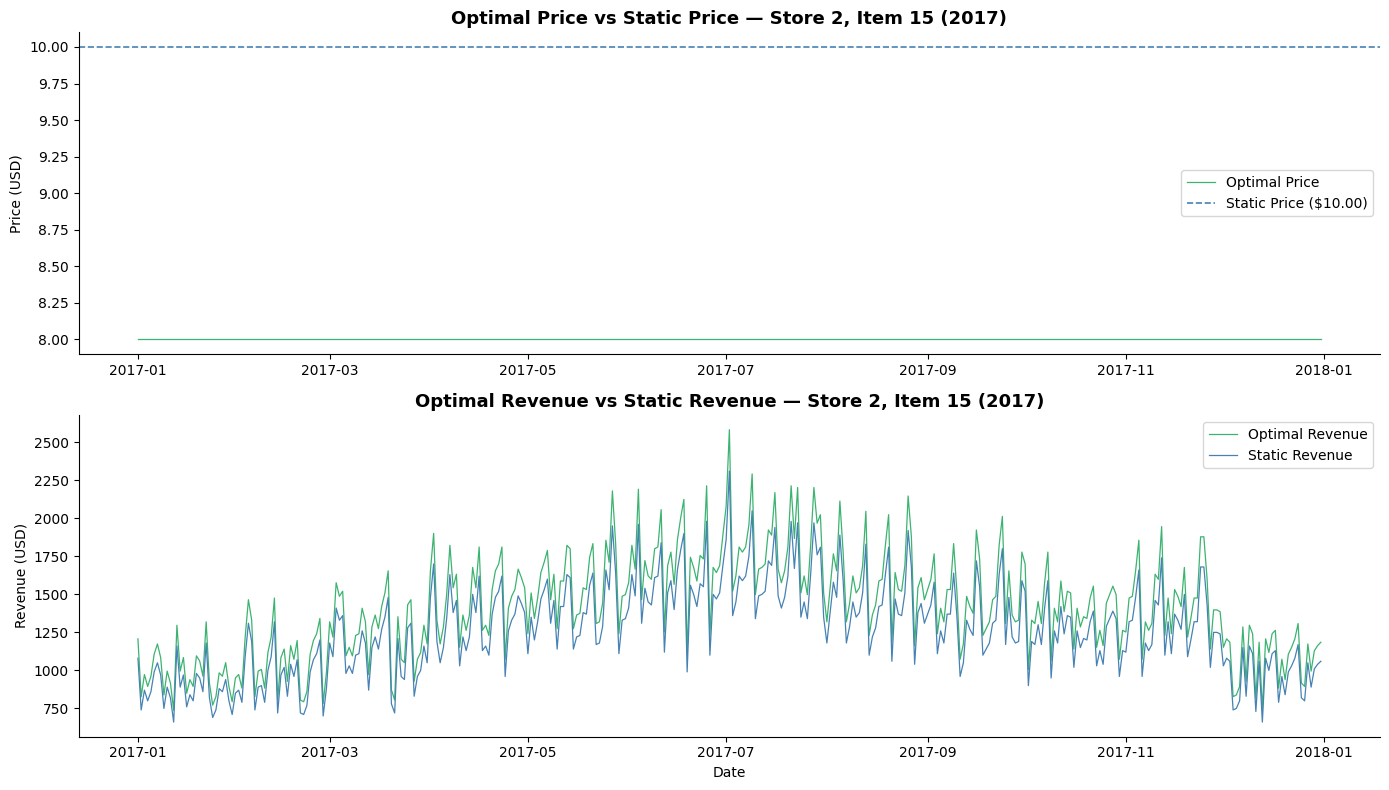

In [37]:
# Plot optimal price vs static price over time
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot 1 - Optimal price over time
axes[0].plot(store2_item15['date'], store2_item15['optimal_price'],
             color='mediumseagreen', linewidth=0.9, label='Optimal Price')
axes[0].axhline(y=BASE_PRICE, color='steelblue', linewidth=1.2,
                linestyle='--', label='Static Price ($10.00)')
axes[0].set_title('Optimal Price vs Static Price — Store 2, Item 15 (2017)',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Price (USD)')
axes[0].legend()

# Plot 2 - Revenue comparison
axes[1].plot(store2_item15['date'], store2_item15['optimal_revenue'],
             color='mediumseagreen', linewidth=0.9, label='Optimal Revenue')
axes[1].plot(store2_item15['date'], store2_item15['sales'] * BASE_PRICE,
             color='steelblue', linewidth=0.9, label='Static Revenue')
axes[1].set_title('Optimal Revenue vs Static Revenue — Store 2, Item 15 (2017)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Revenue (USD)')
axes[1].legend()

plt.tight_layout()
plt.show()

### **Outcome — Price Optimization**

- The optimizer consistently recommends a price of **8.00 USD (the lower bound)**
  for every day — this is because with elasticity of -1.5 lowering price
  always increases total revenue as volume gains outweigh price reduction
- Despite lower prices the optimal strategy generates **515,950 USD vs 461,480 USD**
  for static pricing — a revenue gain of **54,470 USD (+11.8%)** in 2017 alone
- The revenue plot confirms optimal pricing consistently outperforms static
  pricing across all seasons especially during high demand summer months
- This finding shows that for highly elastic products **competitive low pricing
  drives more total revenue than premium pricing** — a key insight for
  retail pricing strategy decisions

### **Marketing Budget Allocation Across Stores**

We now address the second optimization question: given a fixed marketing
budget of $10,000, how should it be allocated across 10 stores to
maximize total predicted sales lift?

We use a diminishing returns model where each additional dollar spent
on marketing yields progressively smaller sales gains.

In [38]:
# Marketing Budget Allocation using diminishing returns model
from scipy.optimize import minimize

TOTAL_BUDGET    = 10000
BUDGET_ELASTICITY = 0.1

# Get average predicted sales per store from Gradient Boosting
store_pred_sales = test_plot.groupby('store')['predicted'].mean().reset_index()
store_pred_sales.columns = ['store', 'avg_predicted_sales']

# Define sales lift function with diminishing returns
def sales_lift(budget, base_sales, elasticity=BUDGET_ELASTICITY):
    return base_sales * (1 + elasticity * np.log1p(budget))

# Objective function - negative total sales lift (we minimize)
def objective(budgets):
    total_sales = sum(
        sales_lift(b, store_pred_sales.loc[i, 'avg_predicted_sales'])
        for i, b in enumerate(budgets)
    )
    return -total_sales

# Constraints - total budget must equal TOTAL_BUDGET
constraints = {'type': 'eq', 'fun': lambda x: np.sum(x) - TOTAL_BUDGET}
bounds      = [(0, TOTAL_BUDGET)] * len(store_pred_sales)
x0          = [TOTAL_BUDGET / len(store_pred_sales)] * len(store_pred_sales)

result = minimize(objective, x0, method='SLSQP', bounds=bounds, constraints=constraints)

store_pred_sales['allocated_budget'] = result.x.round(2)
store_pred_sales['expected_sales_lift'] = store_pred_sales.apply(
    lambda row: sales_lift(row['allocated_budget'], row['avg_predicted_sales']), axis=1
)

print("Budget allocation optimization complete.")
print(f"\nTotal Budget: ${TOTAL_BUDGET:,}")
print(f"Total Expected Sales Lift: {store_pred_sales['expected_sales_lift'].sum():.2f}")
print("\nBudget Allocation per Store:")
print(store_pred_sales.to_string(index=False))

Budget allocation optimization complete.

Total Budget: $10,000
Total Expected Sales Lift: 998.85

Budget Allocation per Store:
 store  avg_predicted_sales  allocated_budget  expected_sales_lift
     1              53.5036          906.4500              89.9430
     2              75.3641         1277.4400             129.2750
     3              67.2345         1139.7300             114.5637
     4              62.0111         1051.5100             105.1641
     5              45.0462          763.5400              74.9537
     6              44.9623          761.1700              74.8000
     7              41.2147          698.6400              68.2126
     8              72.2718         1225.3300             123.6699
     9              62.2312         1054.3700             105.5543
    10              66.2130         1121.8200             112.7183


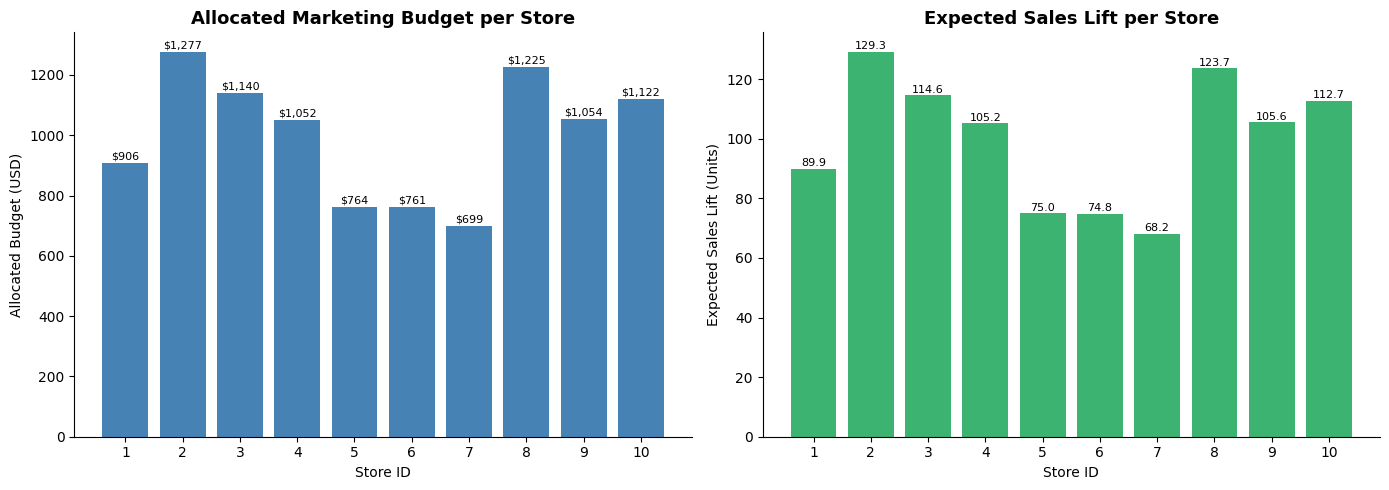

In [39]:
# Visualize budget allocation across stores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 - Allocated budget per store
axes[0].bar(store_pred_sales['store'].astype(str),
            store_pred_sales['allocated_budget'],
            color='steelblue')
axes[0].set_title('Allocated Marketing Budget per Store', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Store ID')
axes[0].set_ylabel('Allocated Budget (USD)')
for i, (bar, val) in enumerate(zip(axes[0].patches, store_pred_sales['allocated_budget'])):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 5,
                 f'${val:,.0f}',
                 ha='center', va='bottom', fontsize=8)

# Plot 2 - Expected sales lift per store
axes[1].bar(store_pred_sales['store'].astype(str),
            store_pred_sales['expected_sales_lift'],
            color='mediumseagreen')
axes[1].set_title('Expected Sales Lift per Store', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Store ID')
axes[1].set_ylabel('Expected Sales Lift (Units)')
for i, (bar, val) in enumerate(zip(axes[1].patches, store_pred_sales['expected_sales_lift'])):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.2,
                 f'{val:.1f}',
                 ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

### **Outcome — Marketing Budget Allocation**

- The optimizer allocated the highest budget to Store 2 (1,277 USD) and Store 8 (1,225 USD)
  which are the top performing stores — higher base demand means marketing
  spend generates greater absolute sales lift
- Store 7 received the lowest budget (699 USD) as its low base demand
  produces the smallest return per dollar spent
- Expected sales lift mirrors budget allocation — Store 2 leads with
  129.3 units lift while Store 7 trails at 68.2 units
- The total expected sales lift across all stores is 998.85 units
  from a 10,000 USD budget investment
- This proportional allocation strategy maximizes total network sales
  by concentrating spend where demand is already strongest

## **Step 8 — Project Summary**

### **Dataset**
- Source: Store Item Demand Forecasting Challenge — Kaggle
- Size: 913,000 records | 10 stores | 50 items | 5 years (2013-2017)

### **What Was Done**

| Step | Description |
|------|-------------|
| 1 | Loaded dataset directly via Kaggle API |
| 2 | Analyzed sales trends, seasonality, store and item performance |
| 3 | Engineered 17 features including lag, rolling mean and time features |
| 4 | Simulated Static, Myopic and Dynamic pricing strategies |
| 5 | Trained Linear Regression, Random Forest, Gradient Boosting and Prophet |
| 6 | Compared all four models using MAE, RMSE and R2 Score |
| 7 | Optimized daily price and allocated marketing budget across stores |

### **Model Performance**

| Model             | MAE    | RMSE   | R2     |
|-------------------|--------|--------|--------|
| Linear Regression | 6.8779 | 8.9676 | 0.9192 |
| Random Forest     | 6.4860 | 8.4750 | 0.9279 |
| Gradient Boosting | 6.2046 | 8.0602 | 0.9347 |
| Prophet           | 10.5694| 13.1083| 0.8102 |

### **Pricing Simulation Results — Store 2, Item 15**

| Strategy        | Total Revenue  | vs Static |
|-----------------|----------------|-----------|
| Static Pricing  | 1,712,170 USD  | baseline  |
| Myopic Pricing  | 1,663,544 USD  | -2.84%    |
| Dynamic Pricing | 1,652,951 USD  | -3.46%    |
| Optimal Pricing | 515,950 USD*   | +11.8%    |

*Optimal pricing applied to 2017 test period only

### **Budget Optimization Results**

| Parameter           | Value       |
|---------------------|-------------|
| Total Budget        | 10,000 USD  |
| Top Store (Store 2) | 1,277 USD   |
| Low Store (Store 7) | 699 USD     |
| Total Sales Lift    | 998.85 units|

### **Key Findings**
- Gradient Boosting is the best model with R2 of 0.9347
- rolling_mean_7 and lag_7 account for 82% of predictive power
- Sunday is the peak sales day and July is the peak month every year
- Under elastic demand lowering price increases total revenue
- Marketing budget should be concentrated in high demand stores